In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = fetch_olivetti_faces()
X = data.data
Y = data.target
images = data.images

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Admin\scikit_learn_data


In [3]:
print("Data Shape:", X.shape)
print("Target Shape:", Y.shape)
print("There are", len(np.unique(Y)), "unique persons in the dataset")
print("Size of each image is:", images.shape[1], "x", images.shape[2])

Data Shape: (400, 4096)
Target Shape: (400,)
There are 40 unique persons in the dataset
Size of each image is: 64 x 64


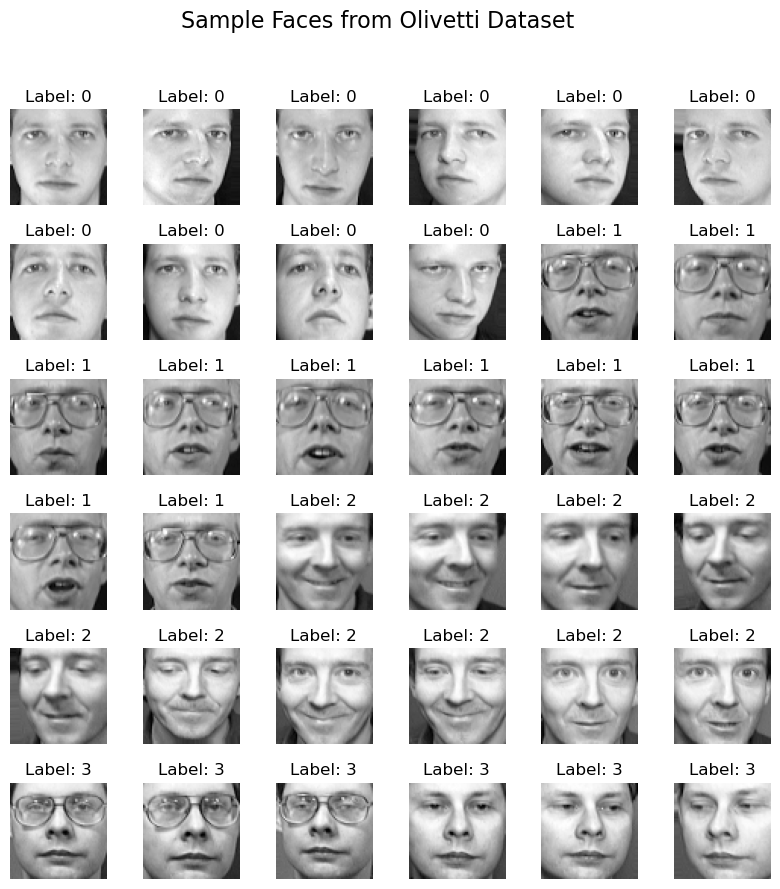

In [8]:
def print_faces(images, target, top_n=36):
    top_n = min(top_n, len(images))
    grid_size = int(np.ceil(np.sqrt(top_n)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    fig.subplots_adjust(hspace=0.4)
    for i, ax in enumerate(axes.flat):
        if i < top_n:
            ax.imshow(images[i], cmap='gray')
            ax.set_title(f"Label: {target[i]}")
            ax.axis('off')
        else:
            ax.axis('off')
    plt.suptitle("Sample Faces from Olivetti Dataset", fontsize=16)
    plt.show()

print_faces(images, Y, top_n=36)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [11]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

In [12]:
gnb_acc = accuracy_score(y_test, y_pred_gnb)
print("\n[Gaussian Naive Bayes]")
print("Accuracy: {:.2f}%".format(gnb_acc * 100))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gnb))


[Gaussian Naive Bayes]
Accuracy: 74.17%
Confusion Matrix:
 [[3 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 4]]


In [15]:
nb = MultinomialNB() 
nb.fit(X_train, y_train) 
y_pred = nb.predict(X_test) 
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2) 
print(f"Multinomial Naive Bayes Accuracy: {accuracy}%") 

Multinomial Naive Bayes Accuracy: 75.83%


In [16]:
misclassified_idx = np.where(y_pred_gnb != y_test)[0]
print(f"\nNumber of misclassified images: {len(misclassified_idx)}")
print(f"Accuracy: {round((1 - len(misclassified_idx)/len(y_test)) * 100, 2)}%")


Number of misclassified images: 31
Accuracy: 74.17%


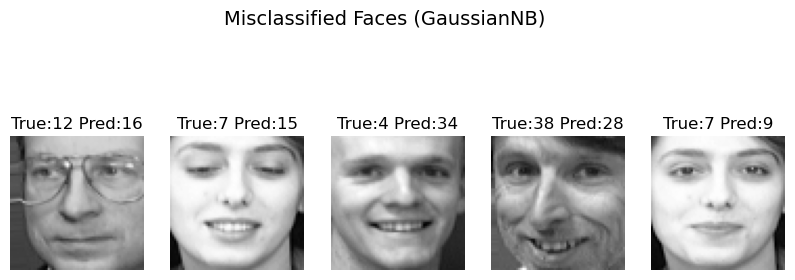

In [19]:
plt.figure(figsize=(10, 4))
for i in range(min(5, len(misclassified_idx))):
    idx = misclassified_idx[i]
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(64, 64), cmap='gray')
    plt.title(f"True:{y_test[idx]} Pred:{y_pred_gnb[idx]}")
    plt.axis('off')
plt.suptitle("Misclassified Faces (GaussianNB)", fontsize=14)
plt.show()